In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('airline_passengers.csv',index_col='Month',parse_dates=True)

In [ ]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<AxesSubplot:xlabel='Month'>

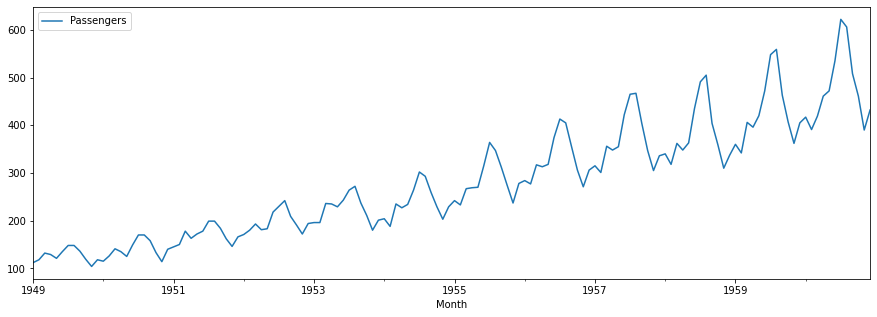

In [4]:
df.plot(figsize=(15,5))

In [5]:
df['1sdiff']=df['Passengers'].diff()

<AxesSubplot:xlabel='Month'>

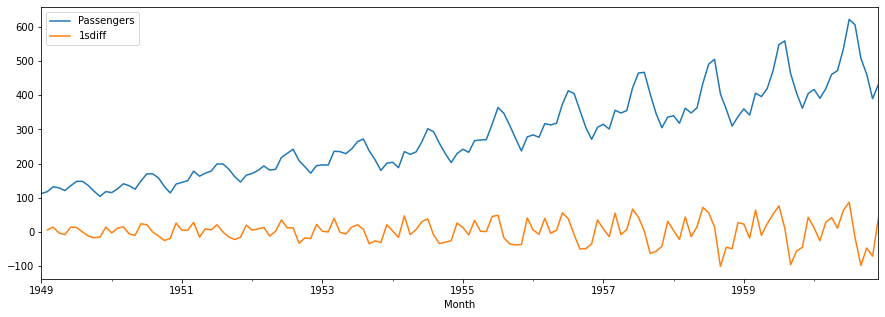

In [6]:
df.plot(figsize=(15,5))

In [7]:
df['LogPassengers']=np.log(df['Passengers'])

<AxesSubplot:xlabel='Month'>

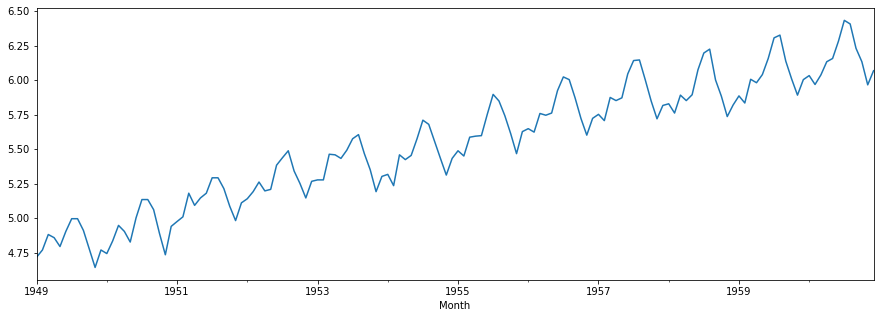

In [8]:
df['LogPassengers'].plot(figsize=(15,5))

In [9]:
from statsmodels.tsa.arima.model import ARIMA

In [10]:
df.index.freq='MS'

In [11]:
Ntest=12
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [12]:
train_idx=df.index <= train.index[-1]
test_idx= df.index > train.index [-1]

In [13]:
arima = ARIMA (train['Passengers'],order=(1,0,0))

In [14]:
arima_result= arima.fit()

In [15]:
df.loc[train_idx, 'AR(1)']=arima_result.predict(strat=train.index[0]
                                                ,end=train.index[-1])

<AxesSubplot:xlabel='Month'>

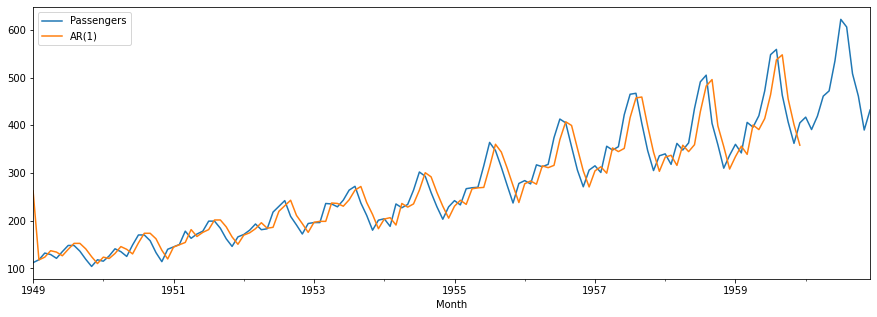

In [16]:
df[['Passengers','AR(1)']].plot(figsize=(15,5))

In [17]:
prediction_result=arima_result.get_forecast(Ntest)
forcast=prediction_result.predicted_mean
df.loc[test_idx,'AR(1)']=forcast

<AxesSubplot:xlabel='Month'>

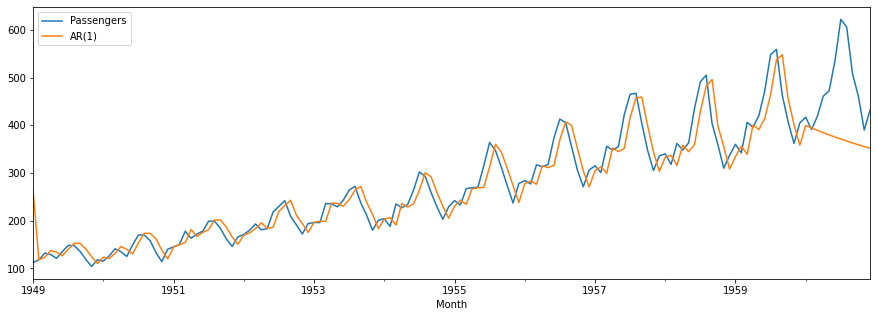

In [18]:
df[['Passengers','AR(1)']].plot(figsize=(15,5))

In [19]:
type(prediction_result)

statsmodels.tsa.statespace.mlemodel.PredictionResultsWrapper

In [20]:
prediction_result.conf_int()

,lower Passengers,upper Passengers
1960-01-01,338.658210,460.451500
1960-02-01,309.826171,478.809354
1960-03-01,287.732168,490.829379
1960-04-01,269.338256,499.534230
1960-05-01,253.432284,506.121347
1960-06-01,239.373402,511.217437
1960-07-01,226.768868,515.201638
1960-08-01,215.354570,518.324977
1960-09-01,204.941150,520.764224
1960-10-01,195.386337,522.649550


In [21]:
def plot_fit_and_forecast(result):
    fig,ax=plt.subplots(figsize=(15,5))
    ax.plot(df['Passengers'],label='data')
    
    train_pred=result.fittedvalues
    ax.plot(train.index,train_pred,color='green',label='fitted')
    
    prediction_result=result.get_forecast(Ntest)
    forcast=prediction_result.predicted_mean
    ax.plot(test.index,forcast,label='forcast')

    
    conf_int= prediction_result.conf_int()
    lower,upper=conf_int['lower Passengers'],conf_int['upper Passengers']
    ax.fill_between(test.index,\
        lower,upper, \
            color='red',alpha=.3)
    ax.legend()

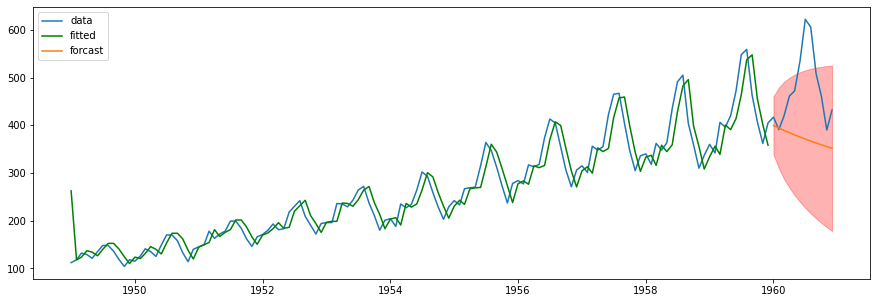

In [22]:
plot_fit_and_forecast(arima_result)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


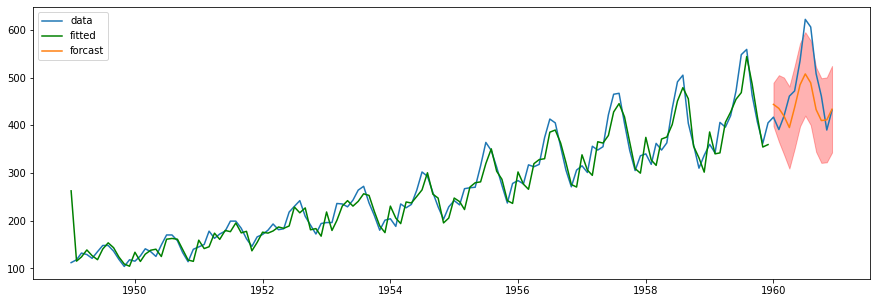

In [23]:
arima=ARIMA(train['Passengers'],order=(10,0,0))
arima_result=arima.fit()
plot_fit_and_forecast(arima_result)


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


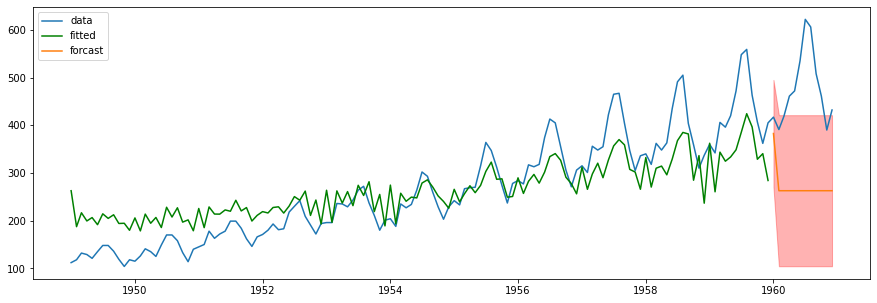

In [24]:
arima=ARIMA(train['Passengers'],order=(0,0,1))
arima_result=arima.fit()
plot_fit_and_forecast(arima_result)

In [25]:
df['LogPassengers']=df['LogPassengers'].diff()

<AxesSubplot:xlabel='Month'>

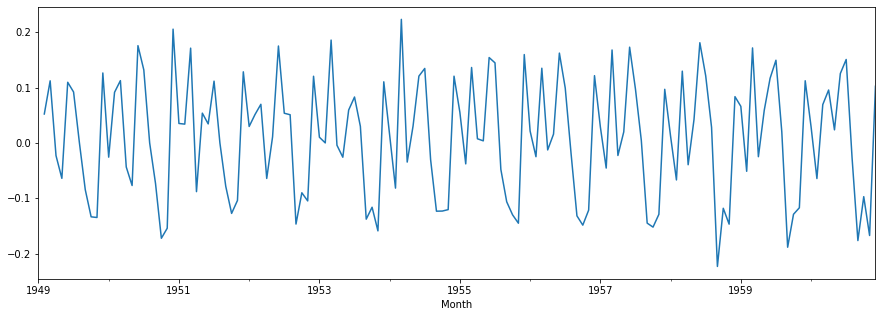

In [26]:
df['LogPassengers'].plot(figsize=(15,5))

In [27]:
arima=ARIMA(train['Passengers'],order=(8,1,1))
arima_result_811=arima.fit()

In [28]:
def plot_fit_and_forecast_int(result,d,col='Passengers'):
    fig,ax=plt.subplots(figsize=(15,5))
    ax.plot(df[col],label='data')
    
    
    
    train_pred=result.predict(start=train.index[d],end=train.index[-1])
    ax.plot(train.index[d:],train_pred,color='green',label='fitted')
    
    prediction_result=result.get_forecast(Ntest)
    forcast=prediction_result.predicted_mean
    ax.plot(test.index,forcast,label='forcast')
    
    
    conf_int= prediction_result.conf_int()
    lower,upper=conf_int[f'lower {col}'],conf_int[f'upper {col}']
    ax.fill_between(test.index,\
        lower,upper, \
            color='red',alpha=.3)
    ax.legend()

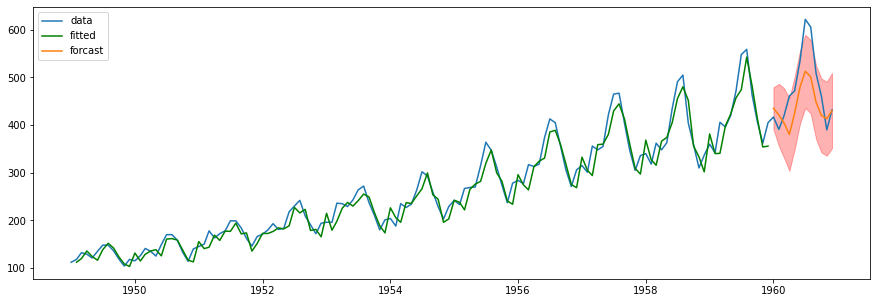

In [29]:
plot_fit_and_forecast_int(arima_result_811,1)

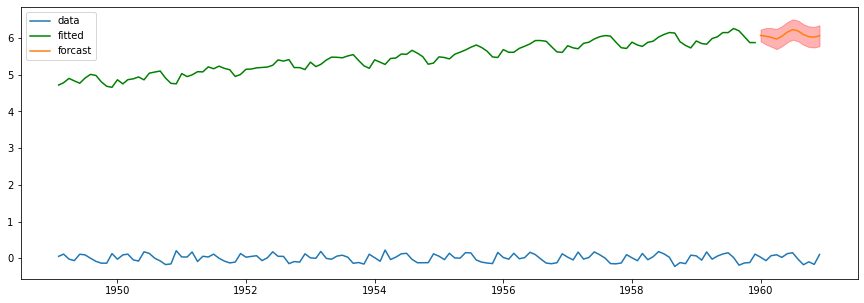

In [30]:
arima=ARIMA(train['LogPassengers'],order=(8,1,1))
arima_result_log811=arima.fit()
plot_fit_and_forecast_int(arima_result_log811, 1 ,col='LogPassengers')

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


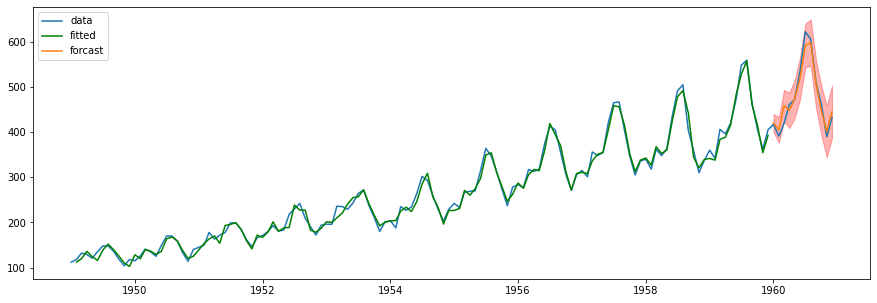

In [48]:
arima=ARIMA(train['Passengers'],order=(12,1,0))
arima_result_1210=arima.fit()
plot_fit_and_forecast_int(arima_result_1210, 1 ,col='Passengers')

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


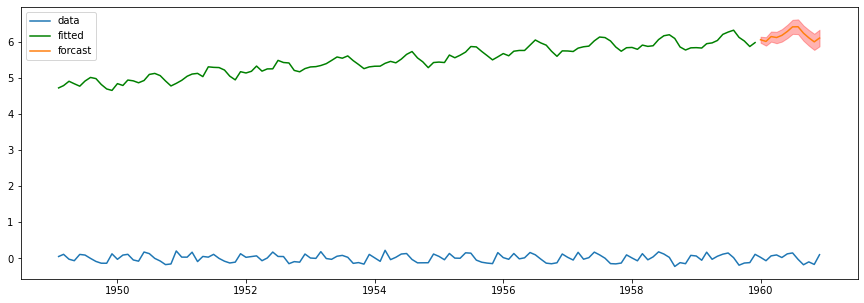

In [45]:
arima=ARIMA(train['LogPassengers'],order=(12,1,0))
arima_result_log1210=arima.fit()
plot_fit_and_forecast_int(arima_result_log1210, 1 ,col='LogPassengers')

In [43]:
def rmse(result,is_logged):
    forcast=result.forecast(Ntest)
    if (is_logged):
        forcast=np.exp(forcast)
    
    t=test['Passengers']
    y=forcast
    return np.sqrt(np.mean((t-y)**2))

In [51]:
print("rmse ARIMA(12,1,0):",rmse(arima_result_1210,False))
print("rmse ARIMA(12,1,0):",rmse(arima_result_log1210,True))
print("rmse ARIMA(8,1,1):",rmse(arima_result_811,False))
print("rmse ARIMA(8,1,1):",rmse(arima_result_log811,True))




rmse ARIMA(12,1,0): 17.49179400343194
rmse ARIMA(12,1,0): 16.097192102889153
rmse ARIMA(8,1,1): 59.064587494106505
rmse ARIMA(8,1,1): 61.60553663793547


ACF and PACF

In [1]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

In [3]:
x0=np.random.randn(1000)

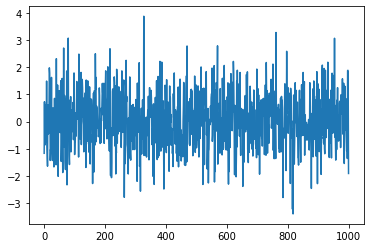

In [4]:
plt.plot(x0)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


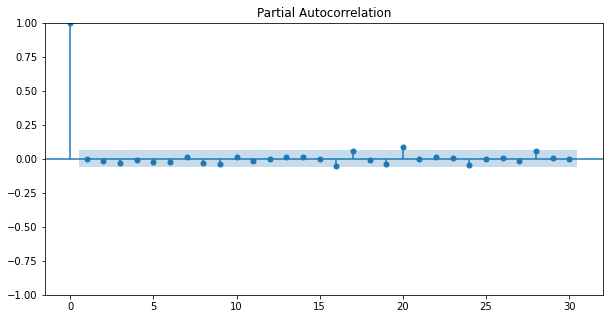

In [9]:
fig,ax= plt.subplots(figsize=(10,5))
plot_pacf(x0,ax=ax);

In [7]:
x1=[0]
for i in range(1000):
    x=.5* x1[-1]+ .1*np.random.randn()
    x1.append(x)
x1=np.array(x1)

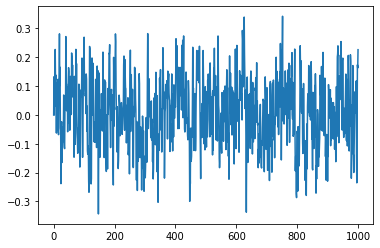

In [8]:
plt.plot(x1)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


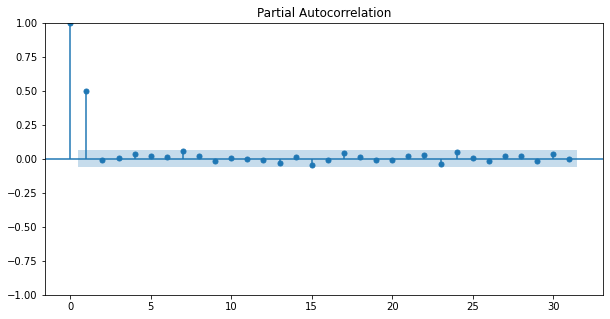

In [10]:
fig,ax= plt.subplots(figsize=(10,5))
plot_pacf(x1,ax=ax);

In [11]:
x1=[0]
for i in range(1000):
    x=-.5* x1[-1]+ .1*np.random.randn()
    x1.append(x)
x1=np.array(x1)

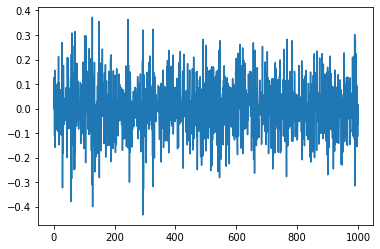

In [12]:
plt.plot(x1)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


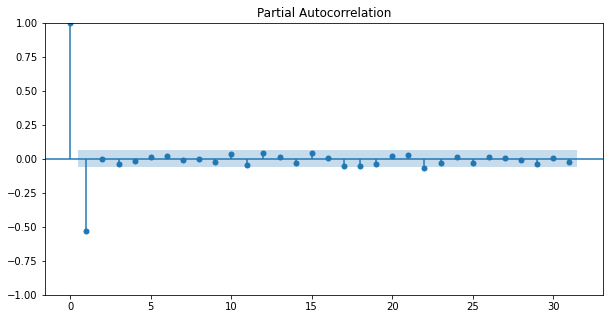

In [13]:
fig,ax= plt.subplots(figsize=(10,5))
plot_pacf(x1,ax=ax);

In [17]:
x2=[0,0]
for i in range(1000):
    x=.5* x2[-1]-.3*x2[-2]+ .1*np.random.randn()
    x2.append(x)
x2=np.array(x2)

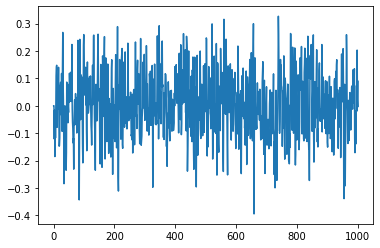

In [18]:
plt.plot(x2)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


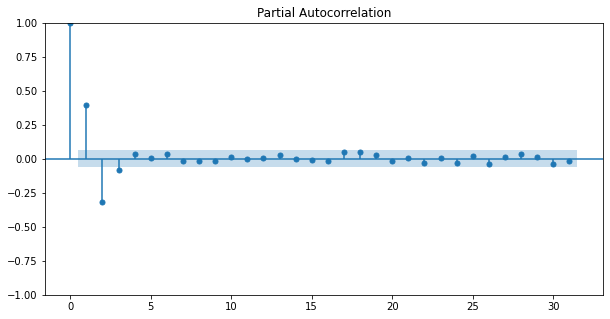

In [19]:
fig,ax= plt.subplots(figsize=(10,5))
plot_pacf(x2,ax=ax);

In [26]:
x5=[0,0,0,0,0]
for i in range(1000):
    x=.5* x5[-1]-.3*x5[-2]-.6*x5[-5]+ .1*np.random.randn()
    x5.append(x)
x5=np.array(x5)

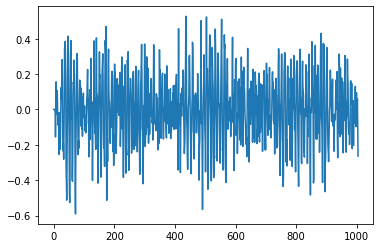

In [27]:
plt.plot(x5)

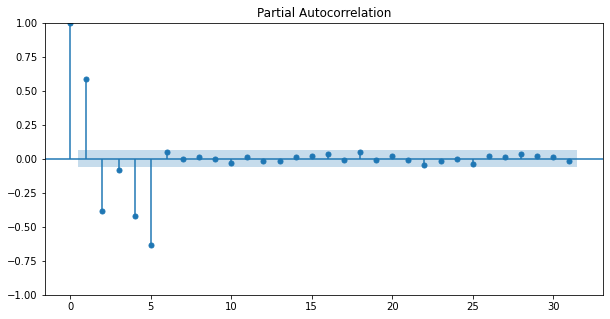

In [28]:
fig,ax= plt.subplots(figsize=(10,5))
plot_pacf(x5,ax=ax);

In [31]:
errors=.1 *np.random.randn(1000)
ma1=[]
for i in range(1000):
    if i>=1:
        x=.5*errors[i-1]+errors[i]
    else:
        x=errors[i]
    ma1.append(x)
ma1=np.array(ma1)

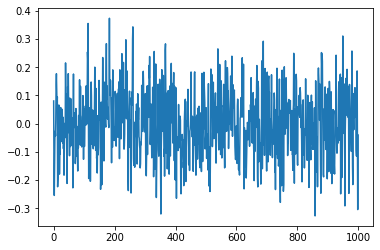

In [32]:
plt.plot(ma1)

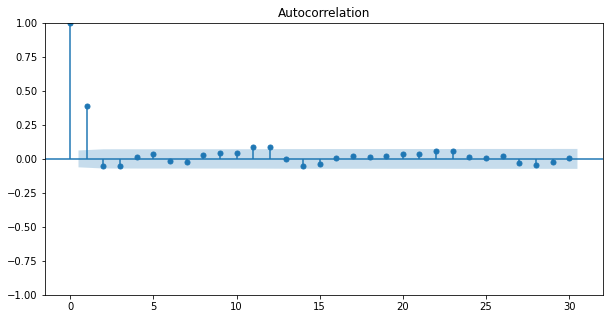

In [33]:
fig,ax= plt.subplots(figsize=(10,5))
plot_acf(ma1,ax=ax);

In [34]:
errors=.1 *np.random.randn(1000)
ma2=[]
for i in range(1000):
    x=.5*errors[i-1]+.3*errors[i-2]+errors[i]
    ma2.append(x)
ma2=np.array(ma2)

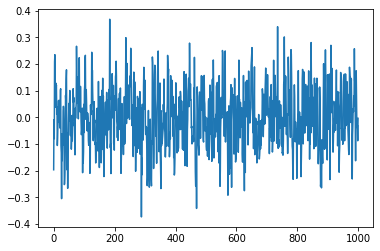

In [36]:
plt.plot(ma2)

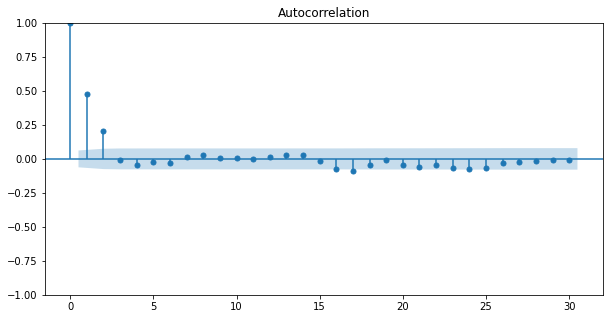

In [37]:
fig,ax= plt.subplots(figsize=(10,5))
plot_acf(ma2,ax=ax);

In [50]:
errors=.1 *np.random.randn(1000)
ma3=[]
for i in range(1000):
    x=.5*errors[i-1]-.3*errors[i-2]-.7*errors[i-3]+errors[i]
    ma3.append(x)
ma3=np.array(ma3)

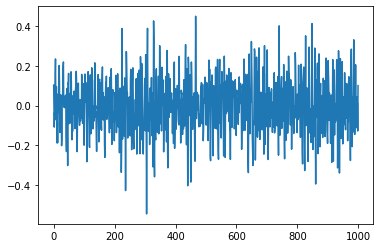

In [51]:
plt.plot(ma3)

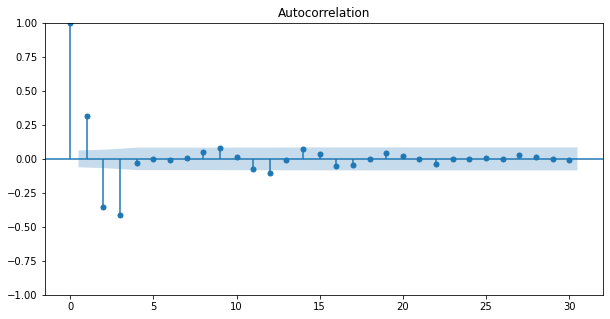

In [52]:
fig,ax= plt.subplots(figsize=(10,5))
plot_acf(ma3,ax=ax);

Auto ARIMA

In [ ]:
df['LogPassengers']=np.log(df['Passengers'])

In [ ]:
Ntest=12
train=df.iloc[:-Ntest]
test=df.iloc[-Ntest:]

In [ ]:
import pmdarima as pm

In [ ]:
model= pm.auto_arima(train['Passengers'],
                     trace=True,
                     suppress_warnings=True,
                     seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.60 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=0.28 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=0.22 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=0.74 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=0.27 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=2.09 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=0.19 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=0.35 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.10 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=0.26 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Wed, 21 Feb 2024   AIC                            905.686
Time:                                    09:17:43   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
test_pred,confint= model.predict(n_periods=Ntest,return_conf_int=True)

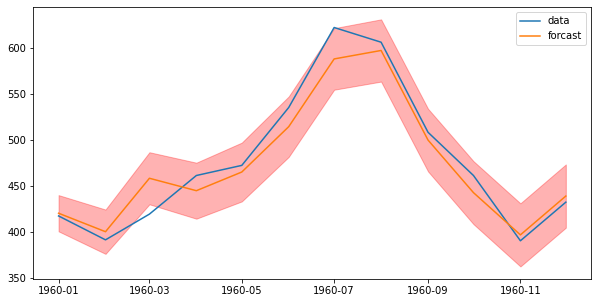

In [61]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(test.index,test['Passengers'],label='data')
ax.plot(test.index,test_pred,label='forcast')
ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

In [ ]:
train_pred=model.predict_in_sample(start=0,end=-1)

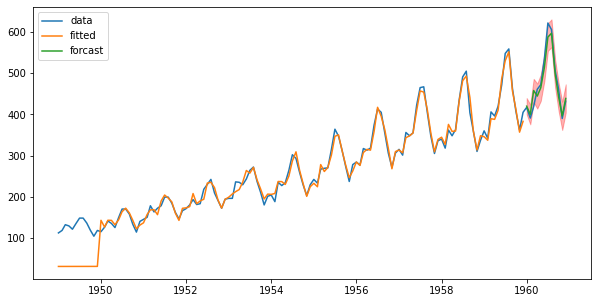

In [67]:
train_pred=model.predict_in_sample(start=0,end=-1)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df.index,df['Passengers'],label='data')
ax.plot(train.index,train_pred,label='fitted')
ax.plot(test.index,test_pred,label='forcast')


ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

In [68]:
logmodel=pm.auto_arima(train['LogPassengers'],
                       trace=True,
                       suppress_warnings=True,
                       seasonal=True,m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-438.643, Time=2.36 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-317.949, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-433.027, Time=0.75 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-383.189, Time=0.54 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-134.983, Time=0.03 sec
 ARIMA(2,0,2)(0,1,1)[12] intercept   : AIC=-444.326, Time=1.85 sec
 ARIMA(2,0,2)(0,1,0)[12] intercept   : AIC=-414.782, Time=0.54 sec
 ARIMA(2,0,2)(0,1,2)[12] intercept   : AIC=-442.330, Time=2.84 sec
 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=-436.164, Time=1.22 sec
 ARIMA(2,0,2)(1,1,2)[12] intercept   : AIC=inf, Time=2.62 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-445.574, Time=0.93 sec
 ARIMA(1,0,2)(0,1,0)[12] intercept   : AIC=-414.732, Time=0.38 sec
 ARIMA(1,0,2)(1,1,1)[12] intercept   : AIC=-442.884, Time=1.14 sec
 ARIMA(1,0,2)(0,1,2)[12] intercept   : AIC=-443.344, Time=2.27 sec
 ARIMA(1,0,2)(1,1,0)[12]

In [69]:
logmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  132
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 229.026
Date:                              Wed, 21 Feb 2024   AIC                           -448.052
Time:                                      09:31:40   BIC                           -434.114
Sample:                                  01-01-1949   HQIC                          -442.392
                                       - 12-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0192      0.009      2.150      0.032       0.002       0.037
ar.L1          0.6007      0.083      7.280      0.000       0.439       0.762
ar.L2          0.2417      0.085      2.854      0.004       0.076       0.408
ma.S.L12      -0.5670      0.105     -5.418      0.000      -0.772      -0.362
sigma2         0.0012      0.000      8.193      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.06
Prob(Q):                              0.99   Prob(JB):                         0.05
Heteroskedasticity (H):               0.36   Skew:                             0.07
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [70]:
test_pred,confint= logmodel.predict(n_periods=Ntest,return_conf_int=True)

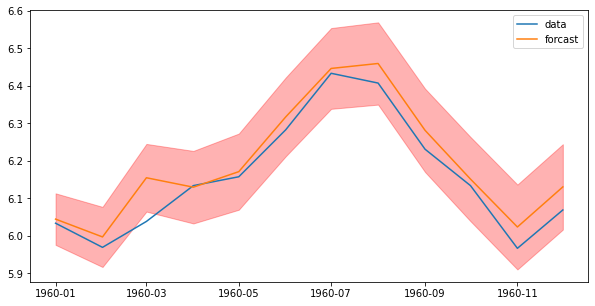

In [73]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(test.index,test['LogPassengers'],label='data')
ax.plot(test.index,test_pred,label='forcast')
ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

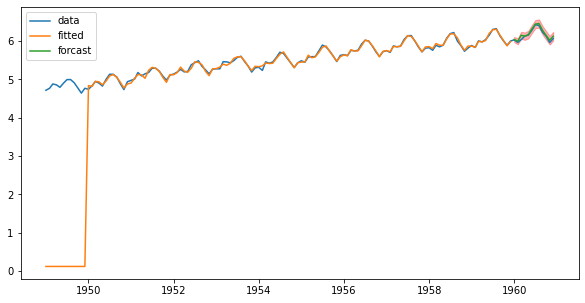

In [74]:
train_pred=logmodel.predict_in_sample(start=0,end=-1)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df.index,df['LogPassengers'],label='data')
ax.plot(train.index,train_pred,label='fitted')
ax.plot(test.index,test_pred,label='forcast')


ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

In [75]:
def rmse(t,y):
    return np.sqrt(np.mean((t-y)**2))

In [76]:
print("Non-logged RMSE:",rmse(test['Passengers'],test_pred))
print("logged RMSE:",rmse(test['Passengers'],np.exp(test_pred)))

Non-logged RMSE: 475.809328711304
logged RMSE: 23.03129977633835


In [77]:
model=pm.auto_arima(train['LogPassengers'],
                    trace=True,
                    suppress_warnings=True,
                    max_p=12, max_q=2, max_order=14,
                    stepwise=True,
                    seasonal=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-211.983, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-214.718, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-216.493, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-212.867, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-221.069, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-216.622, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-222.099, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-217.708, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-215.917, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-228.902, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-217.540, T

In [86]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(4, 1, 2)   Log Likelihood                 133.487
Date:                Wed, 21 Feb 2024   AIC                           -250.974
Time:                        09:42:07   BIC                           -227.973
Sample:                    01-01-1949   HQIC                          -241.628
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0102      0.002      5.447      0.000       0.007       0.014
ar.L1          0.0343      0.122      0.282      0.778      -0.204       0.273
ar.L2          0.4576      0.116      3.950      0.000       0.231       0.685
ar.L3         -0.2380      0.099     -2.396      0.017      -0.433      -0.043
ar.L4         -0.2471      0.107     -2.312      0.021      -0.457      -0.038
ma.L1         -0.0479      0.077     -0.620      0.535      -0.199       0.103
ma.L2         -0.8724      0.075    -11.669      0.000      -1.019      -0.726
sigma2         0.0075      0.001      5.502      0.000       0.005       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.70
Prob(Q):                              0.99   Prob(JB):                         0.06
Heteroskedasticity (H):               1.04   Skew:                             0.22
Prob(H) (two-sided):                  0.91   Kurtosis:                         2.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [87]:
test_pred,confint= model.predict(n_periods=Ntest,return_conf_int=True)

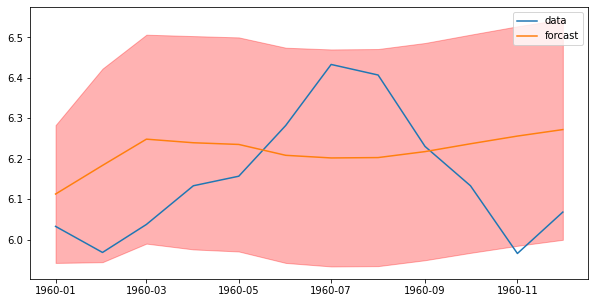

In [90]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(test.index,test['LogPassengers'],label='data')
ax.plot(test.index,test_pred,label='forcast')
ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

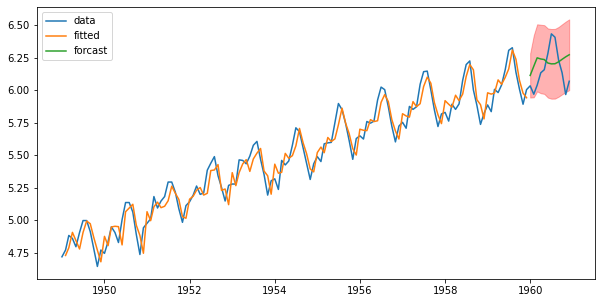

In [93]:
train_pred=model.predict_in_sample(start=1,end=-1)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(df.index,df['LogPassengers'],label='data')
ax.plot(train.index[1:],train_pred,label='fitted')
ax.plot(test.index,test_pred,label='forcast')


ax.fill_between(test.index,\
    confint[:,0],confint[:,1],\
        color='red',alpha=.3)
ax.legend();

In [94]:
rmse(test['Passengers'],np.exp(test_pred))

83.40806057702812

Auto ARIMA stocks

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pmdarima as pm

In [30]:
df=pd.read_csv('sp500sub.csv',index_col='Date',parse_dates=True)

In [31]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [32]:
goog=df.loc[df.Name=="GOOG"]['Close']

<AxesSubplot:xlabel='Date'>

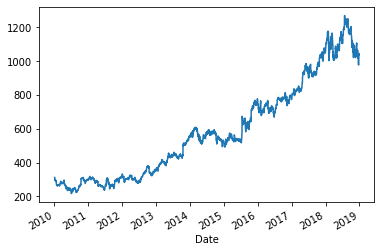

In [33]:
goog.plot()

In [34]:
Ntest=30
train=goog[:-Ntest]
test=goog[-Ntest:]

In [35]:
train_idx=goog.index>=train.index[-1]
test_idx=goog.index<train.index[-1]

In [36]:
model= pm.auto_arima(train,
                     trace=True,
                     suppress_warnings=True,maxiter=10,seasonality=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16270.771, Time=0.76 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16270.383, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16269.726, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16269.492, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16271.123, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16268.077, Time=0.35 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16267.935, Time=0.43 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=16268.277, Time=0.33 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16266.968, Time=0.52 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=16264.983, Time=0.63 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=16266.925, Time=0.55 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16268.907, Time=0.79 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=16265.470, Time=0.21 sec

Best model:  ARIMA(3,1,0)(0,0,0)[0] intercept
Total fit time: 5.080 seconds


In [37]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(3, 1, 0)   Log Likelihood               -8127.491
Date:                Mon, 04 Mar 2024   AIC                          16264.983
Time:                        11:03:29   BIC                          16293.536
Sample:                             0   HQIC                         16275.409
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3104      0.198      1.571      0.116      -0.077       0.698
ar.L1          0.0378      0.012      3.152      0.002       0.014       0.061
ar.L2         -0.0410      0.013     -3.241      0.001      -0.066      -0.016
ar.L3          0.0488      0.012      4.031      0.000       0.025       0.073
sigma2        85.1623      1.033     82.421      0.000      83.137      87.187
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             11790.07
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               6.78   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
model.get_params()

{'maxiter': 10,
 'method': 'lbfgs',
 'order': (3, 1, 0),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (0, 0, 0, 0),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': True}

In [39]:
pred,conf=model.predict(n_periods=Ntest,return_conf_int=True)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [47]:
def plot_result(model,all_data,train,test):
    param=model.get_params()
    d=param['order'][1]
    fitted=model.predict_in_sample(start=d,end=-1)
    pred,conf=model.predict(n_periods=Ntest,return_conf_int=True)
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(all_data.index,all_data,label='data')
    ax.plot(train.index[d:],fitted,label='fitted')
    ax.plot(test.index,pred,label='forcast')
    ax.fill_between(test.index,\
        conf[:,0],conf[:,1],\
        color='red',alpha=.3)
    ax.legend();
    
    

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


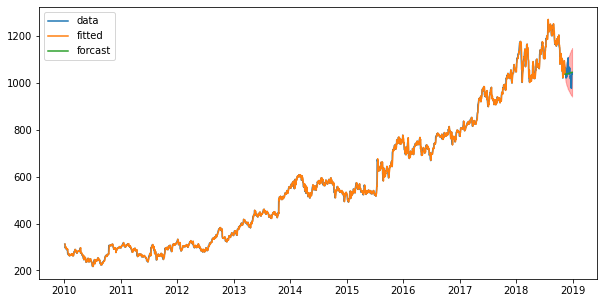

In [48]:
plot_result(model,goog,train,test)

In [93]:
def test_result(train,test,model):
    train_idx=goog.index>=train.index[-1]
    test_idx=goog.index<train.index[-1]
    pred,conf=model.predict(n_periods=Ntest,return_conf_int=True)
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(test.index,test,label='data')
    ax.plot(test.index,pred,label='forcast')
    ax.fill_between(test.index,\
        conf[:,0],conf[:,1],\
        color='red',alpha=.3)
    ax.legend();

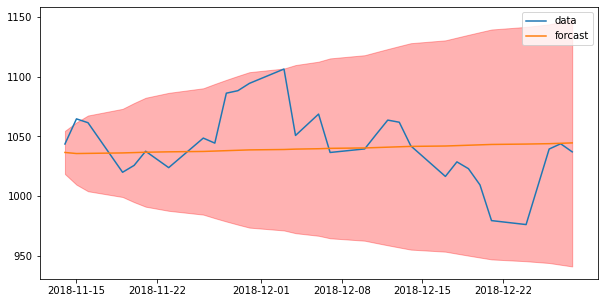

In [61]:
test_result(train,test)

In [49]:
def rmse(y,t):
    return np.sqrt(np.mean((y-t)**2))

In [70]:
print("RMSE ARIMA",rmse(model.predict(Ntest).values,test.values))
print("RMSE Naive",rmse(train.iloc[-1],test))

RMSE ARIMA 30.436602011716605
RMSE Naive 30.029502477261467


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [73]:
aapl=df.loc[df.Name=="AAPL"]['Close']

In [75]:
aapl.head()

Date
2010-01-04    30.572857
2010-01-05    30.625713
2010-01-06    30.138571
2010-01-07    30.082857
2010-01-08    30.282858
Name: Close, dtype: float64

<AxesSubplot:xlabel='Date'>

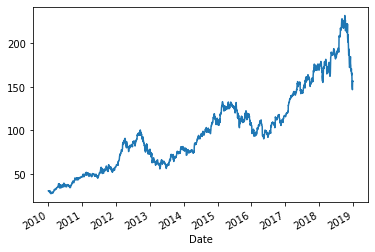

In [76]:
aapl.plot()

In [82]:
train=aapl[:-Ntest]
test=aapl[-Ntest:]

In [83]:
model= pm.auto_arima(train,
                     trace=True,
                     suppress_warnings=True,maxiter=10,seasonality=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8570.296, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8575.329, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8574.709, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8574.392, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8577.622, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8571.650, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8571.332, Time=0.57 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=8572.500, Time=0.50 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=8572.527, Time=0.61 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8574.574, Time=0.34 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8570.852, Time=0.56 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=8570.880, Time=0.53 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=8579.289, Time=0.69 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=8572.973, Time=0.27 sec

Best model:  ARIMA(2,1,2)(0,0,0)

In [84]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -4279.148
Date:                Mon, 04 Mar 2024   AIC                           8570.296
Time:                        11:34:53   BIC                           8604.560
Sample:                             0   HQIC                          8582.808
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0803      0.042      1.896      0.058      -0.003       0.163
ar.L1          0.3755      0.165      2.279      0.023       0.053       0.699
ar.L2         -0.4239      0.176     -2.407      0.016      -0.769      -0.079
ma.L1         -0.3433      0.172     -2.002      0.045      -0.679      -0.007
ma.L2          0.3579      0.183      1.958      0.050      -0.000       0.716
sigma2         2.7182      0.039     69.453      0.000       2.642       2.795
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              6223.04
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               4.23   Skew:                            -0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


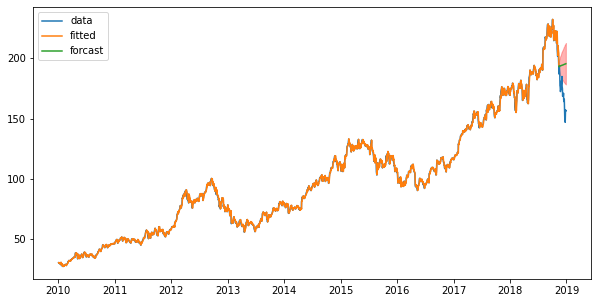

In [86]:
plot_result(model,aapl,train,test)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


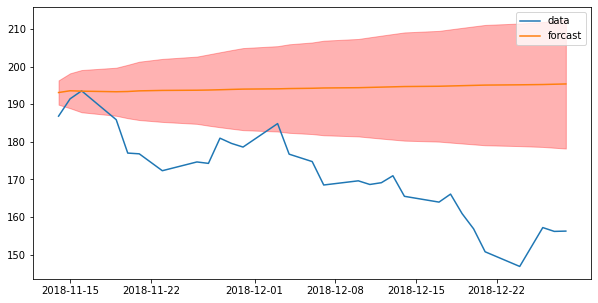

In [94]:
test_result(train,test,model)

In [88]:
print("RMSE ARIMA",rmse(model.predict(Ntest).values,test.values))
print("RMSE Naive",rmse(train.iloc[-1],test))

RMSE ARIMA 26.094960080652257
RMSE Naive 24.02712058667382


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [95]:
ibm=df.loc[df.Name=="IBM"]['Close']

In [96]:
ibm.head()

Date
2010-01-04    132.449997
2010-01-05    130.850006
2010-01-06    130.000000
2010-01-07    129.550003
2010-01-08    130.850006
Name: Close, dtype: float64

<AxesSubplot:xlabel='Date'>

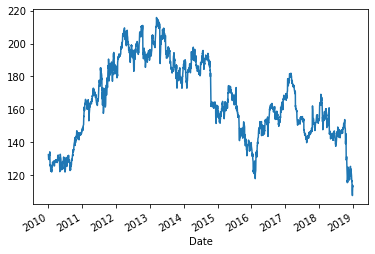

In [97]:
ibm.plot()

In [100]:
train=ibm[:-Ntest]
test=ibm[-Ntest:]

In [101]:
model= pm.auto_arima(train,
                     trace=True,
                     suppress_warnings=True,maxiter=10,seasonality=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=9442.954, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9436.082, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9437.603, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9437.589, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9434.097, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9439.637, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.499 seconds


In [102]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2233
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4716.049
Date:                Mon, 04 Mar 2024   AIC                           9434.097
Time:                        11:45:42   BIC                           9439.808
Sample:                             0   HQIC                          9436.183
                               - 2233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.0067      0.055     72.559      0.000       3.898       4.115
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):              5352.76
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.85   Skew:                            -0.77
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


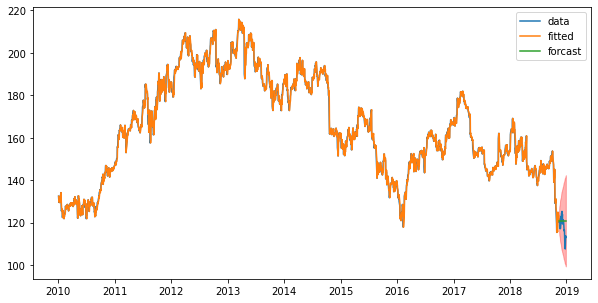

In [104]:
plot_result(model,ibm,train,test)

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


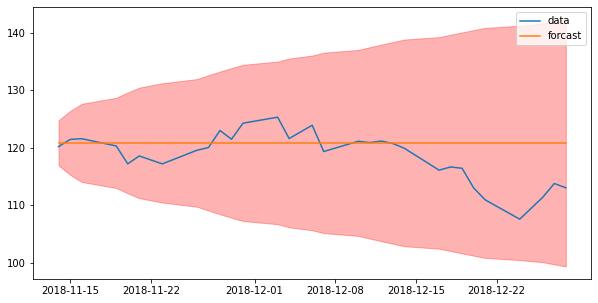

In [105]:
test_result(train,test,model)

In [106]:
print("RMSE ARIMA",rmse(model.predict(Ntest).values,test.values))
print("RMSE Naive",rmse(train.iloc[-1],test))

RMSE ARIMA 4.763157130051095
RMSE Naive 4.763157130051095


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


ACF and PACF in stock price

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [113]:
df=pd.read_csv('sp500sub.csv',index_col='Date',parse_dates=True)

In [114]:
goog=df.loc[df.Name=="GOOG"]

In [115]:
goog.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,312.304413,313.579620,310.954468,312.204773,312.204773,3927000.0,GOOG
2010-01-05,312.418976,312.747742,309.609497,310.829926,310.829926,6031900.0,GOOG
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987100.0,GOOG
2010-01-07,303.562164,303.861053,295.218445,295.940735,295.940735,12876600.0,GOOG
2010-01-08,294.894653,300.498657,293.455048,299.885956,299.885956,9483900.0,GOOG


In [116]:
def log_ret(price):
    log_price=np.log(price)
    return log_price.diff()

In [117]:
goog['LogPrice']=log_ret(goog['Close'])

C:\Users\4623\AppData\Local\Temp\ipykernel_17884\2091867649.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goog['LogPrice']=log_ret(goog['Close'])


In [118]:
goog.head()

,Open,High,Low,Close,Adj Close,Volume,Name,LogPrice
Date,,,,,,,,
2010-01-04,312.304413,313.579620,310.954468,312.204773,312.204773,3927000.0,GOOG,NaN
2010-01-05,312.418976,312.747742,309.609497,310.829926,310.829926,6031900.0,GOOG,-0.004413
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987100.0,GOOG,-0.025532
2010-01-07,303.562164,303.861053,295.218445,295.940735,295.940735,12876600.0,GOOG,-0.023555
2010-01-08,294.894653,300.498657,293.455048,299.885956,299.885956,9483900.0,GOOG,0.013243


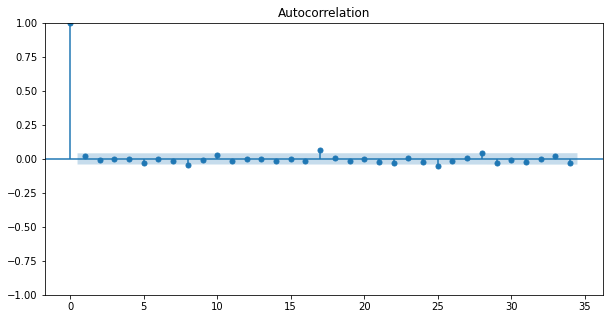

In [122]:
fig,ax=plt.subplots(figsize=(10,5))
plot_acf(goog['LogPrice'].dropna(),ax=ax);


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


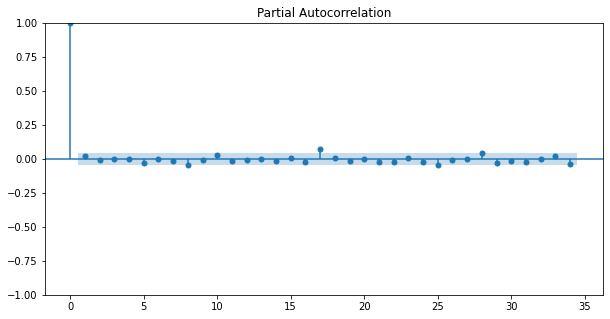

In [123]:
fig,ax=plt.subplots(figsize=(10,5))
plot_pacf(goog['LogPrice'].dropna(),ax=ax);


Sales Data

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pmdarima as pm

In [128]:
df=pd.read_csv('perrin-freres-monthly-champagne.csv',index_col='Month').dropna()

In [130]:
df.columns=['Sales']

In [131]:
df.head()

,Sales
Month,
1964-01,2815.0
1964-02,2672.0
1964-03,2755.0
1964-04,2721.0
1964-05,2946.0


<AxesSubplot:xlabel='Month'>

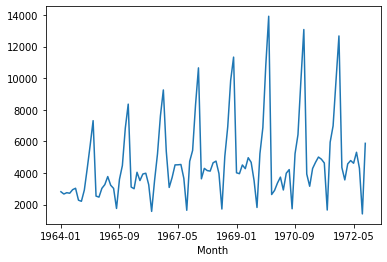

In [132]:
df['Sales'].plot()

In [135]:
Ntest=12
train=df[:-Ntest]
test=df[-Ntest:]

In [136]:
model= pm.auto_arima(train,
                     trace=True,
                     suppress_warnings=True,maxiter=10,seasonality=True,m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=1321.342, Time=0.36 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1315.739, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1314.249, Time=0.13 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1315.169, Time=0.15 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1325.791, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1315.489, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1314.184, Time=0.29 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=1316.117, Time=0.41 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1316.055, Time=0.34 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1315.951, Time=0.19 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1316.187, Time=0.39 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1316.405, Time=0.36 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1314.571, Time=0.36 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1318.344, Time=0.43 sec
 ARIMA(1,0,0)(2,1,0

In [137]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   93
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -652.092
Date:                            Mon, 04 Mar 2024   AIC                           1314.184
Time:                                    15:09:35   BIC                           1326.156
Sample:                                01-01-1964   HQIC                          1318.987
                                     - 09-01-1971                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    259.3865    112.882      2.298      0.022      38.142     480.631
ar.L1          0.1961      0.092      2.132      0.033       0.016       0.376
ar.S.L12      -0.1568      0.089     -1.752      0.080      -0.332       0.019
ar.S.L24       0.1383      0.111      1.250      0.211      -0.078       0.355
sigma2      6.067e+05   8.78e+04      6.907      0.000    4.35e+05    7.79e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 3.66
Prob(Q):                              0.47   Prob(JB):                         0.16
Heteroskedasticity (H):               2.10   Skew:                            -0.11
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [139]:
model.get_params()

{'maxiter': 10,
 'method': 'lbfgs',
 'order': (1, 0, 0),
 'out_of_sample_size': 0,
 'scoring': 'mse',
 'scoring_args': {},
 'seasonal_order': (2, 1, 0, 12),
 'start_params': None,
 'suppress_warnings': True,
 'trend': None,
 'with_intercept': True}

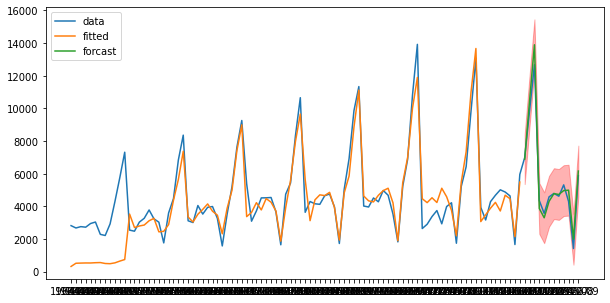

In [138]:
plot_result(model,df,train,test)

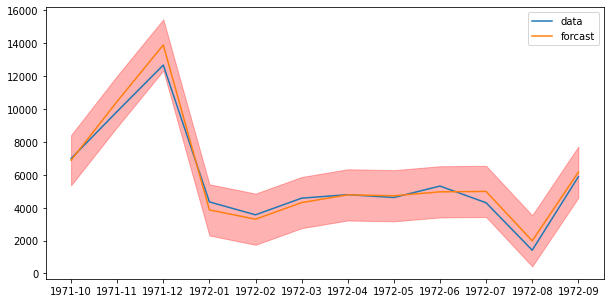

In [140]:
test_result(train,test,model)

In [141]:
print("RMSE ARIMA",rmse(model.predict(Ntest).values,test.values))
print("RMSE Naive",rmse(train.iloc[-1],test))

RMSE ARIMA 4250.4251975019215
RMSE Naive Sales    2864.149423
dtype: float64


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [147]:
from sklearn.metrics import r2_score

In [152]:
r2_score(test['Sales'],model.predict(Ntest))

0.9665971966694912